In [18]:
#Import the necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

os.makedirs("../data", exist_ok=True)

import warnings
warnings.filterwarnings("ignore")

In [19]:
#read csv file
df=pd.read_csv('Insurance claims data.csv')
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [20]:
#display of the number of rows and columns
print("Shape:",df.shape)

Shape: (58592, 41)


In [21]:
#checks for the data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  object 
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  airb

In [22]:
#Checking for the data characteristics
df.describe()

,subscription_length,vehicle_age,customer_age,region_density,airbags,displacement,cylinder,turning_radius,length,width,gross_weight,ncap_rating,claim_status
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000
mean,6.111688,1.388473,44.823935,18826.858667,3.137066,1162.355851,3.626963,4.852893,3850.476891,1672.233667,1385.276813,1.759950,0.063968
std,4.142790,1.134413,6.935604,17660.174792,1.832641,266.304786,0.483616,0.228061,311.457119,112.089135,212.423085,1.389576,0.244698
min,0.000000,0.000000,35.000000,290.000000,1.000000,796.000000,3.000000,4.500000,3445.000000,1475.000000,1051.000000,0.000000,0.000000
25%,2.100000,0.400000,39.000000,6112.000000,2.000000,796.000000,3.000000,4.600000,3445.000000,1515.000000,1185.000000,0.000000,0.000000
50%,5.700000,1.200000,44.000000,8794.000000,2.000000,1197.000000,4.000000,4.800000,3845.000000,1735.000000,1335.000000,2.000000,0.000000
75%,10.400000,2.200000,49.000000,27003.000000,6.000000,1493.000000,4.000000,5.000000,3995.000000,1755.000000,1510.000000,3.000000,0.000000
max,14.000000,20.000000,75.000000,73430.000000,6.000000,1498.000000,4.000000,5.200000,4300.000000,1811.000000,1720.000000,5.000000,1.000000


In [23]:
#Data cleaning and preprocessing
#Checks for duplicates
print("Duplicates:",df.duplicated().sum())

Duplicates: 0


In [24]:
#Checks for missing values
print("\nMissing values:\n",df.isnull().sum())



Missing values:
 policy_id                           0
subscription_length                 0
vehicle_age                         0
customer_age                        0
region_code                         0
region_density                      0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
steering_type                       0
turning_radius                      0
length                              0
width                           

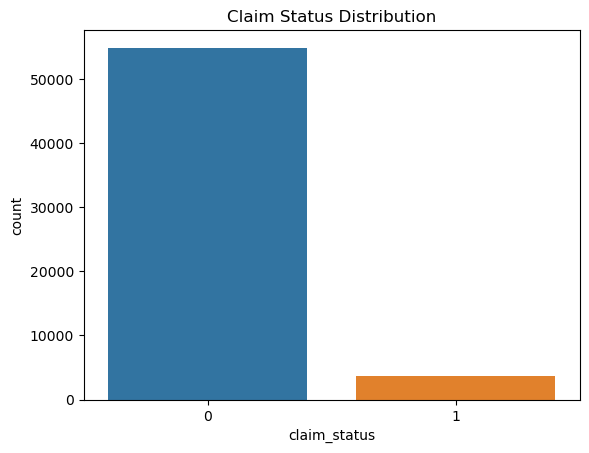

0    93.603222
1     6.396778
Name: claim_status, dtype: float64

In [25]:
#Target variable analysis
sns.countplot(x="claim_status", data=df)
plt.title("Claim Status Distribution")
plt.show()

# Percentage distribution
df["claim_status"].value_counts(normalize=True) * 100

In [30]:
#identified numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['subscription_length', 'vehicle_age', 'customer_age', 'region_density',
       'airbags', 'displacement', 'cylinder', 'turning_radius', 'length',
       'width', 'gross_weight', 'ncap_rating', 'claim_status'],
      dtype='object')

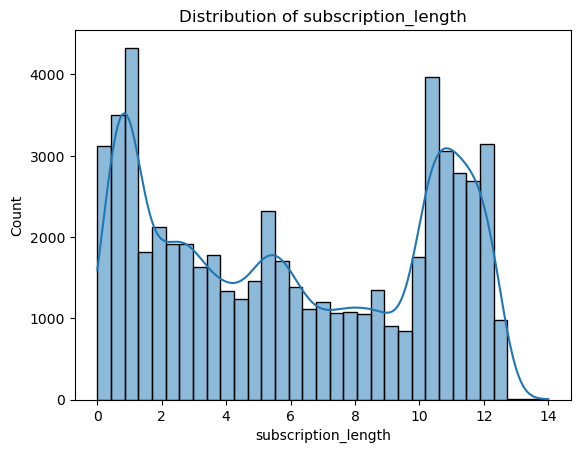

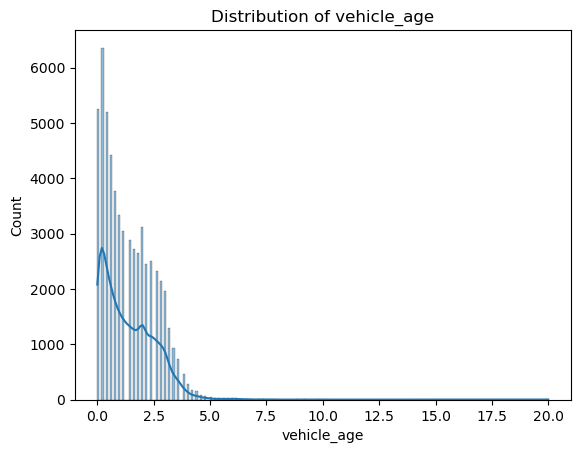

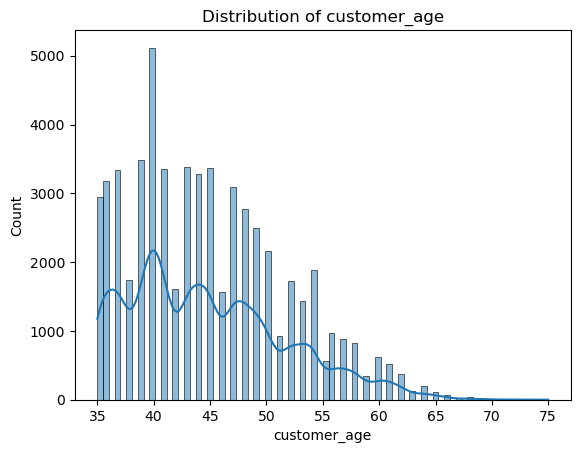

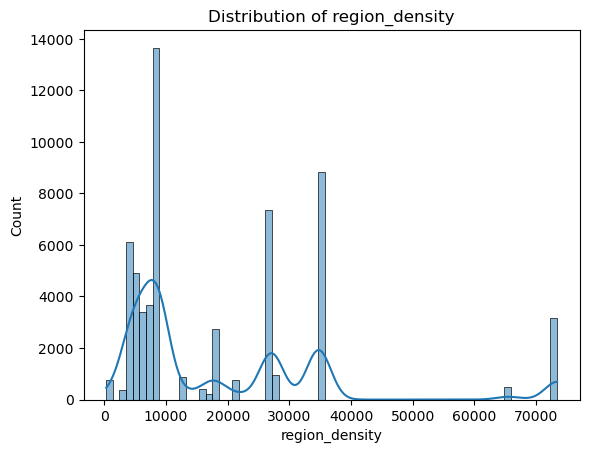

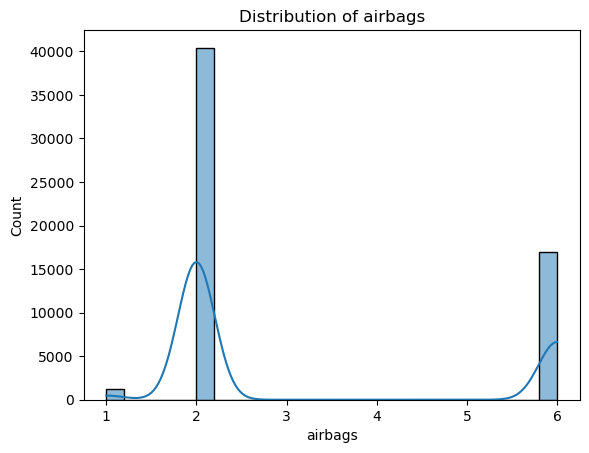

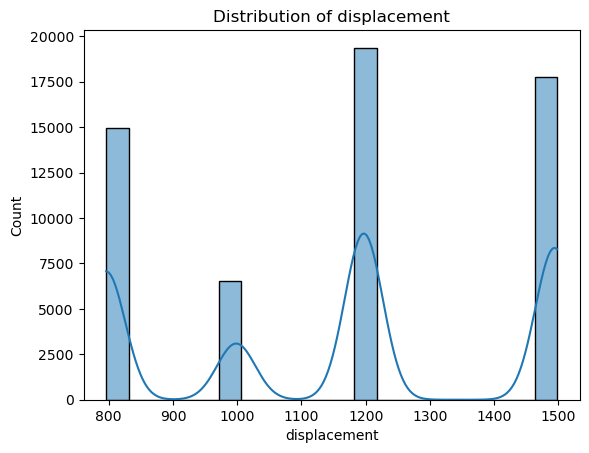

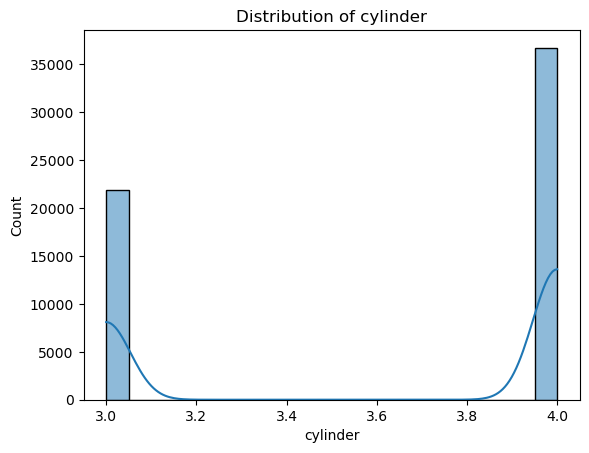

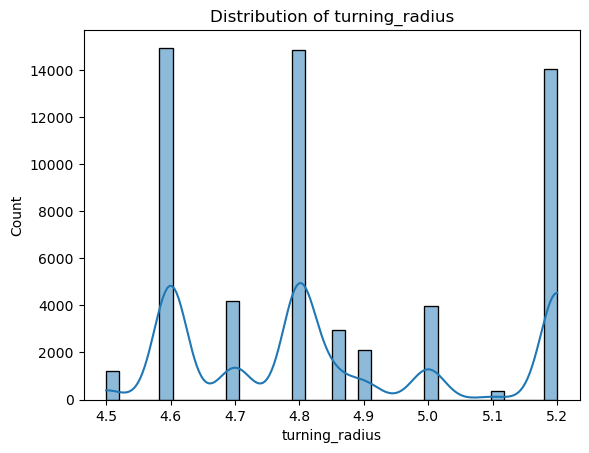

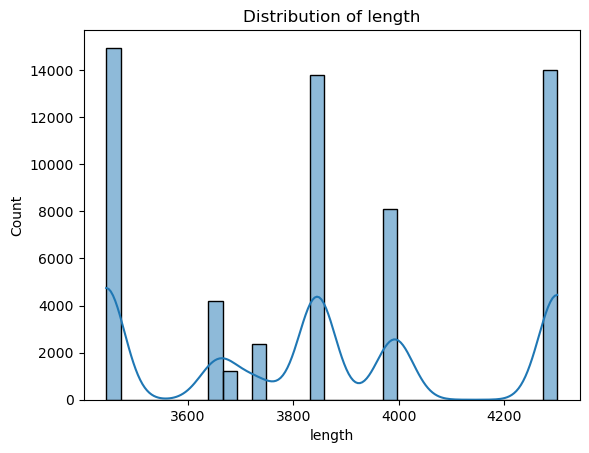

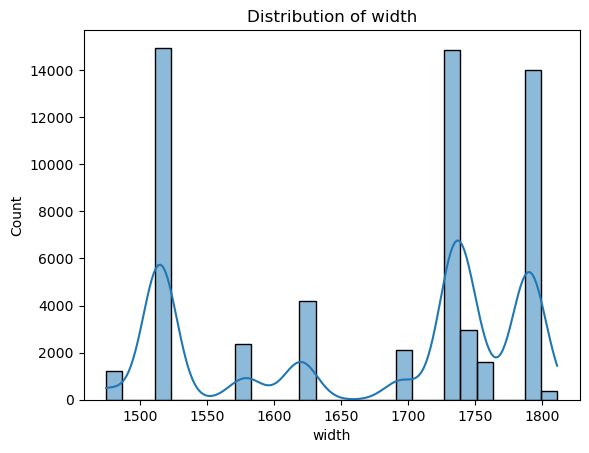

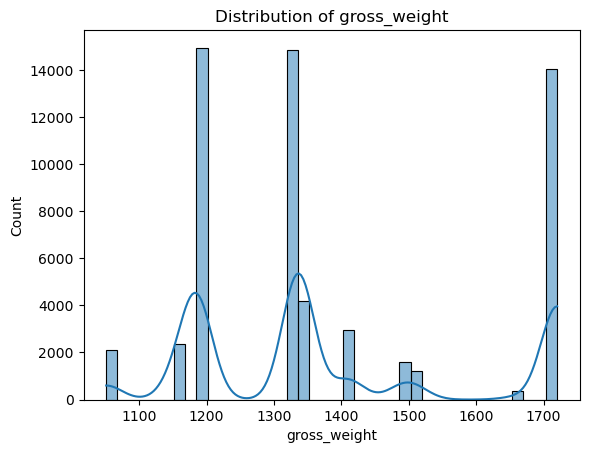

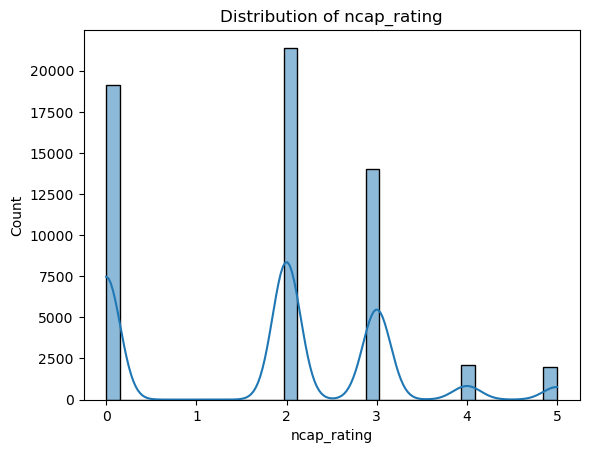

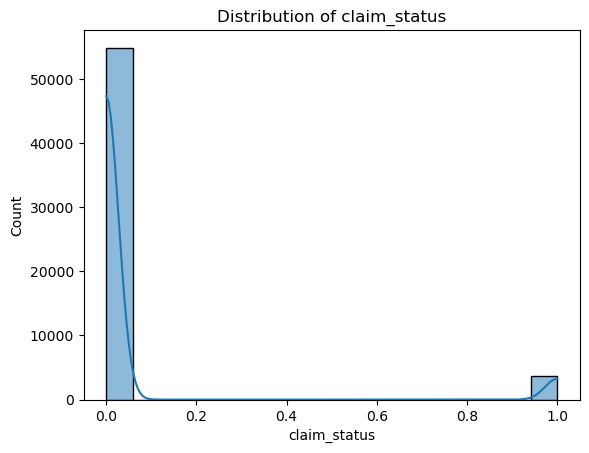

In [31]:
#Distribution plots
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

<Figure size 1200x800 with 0 Axes>

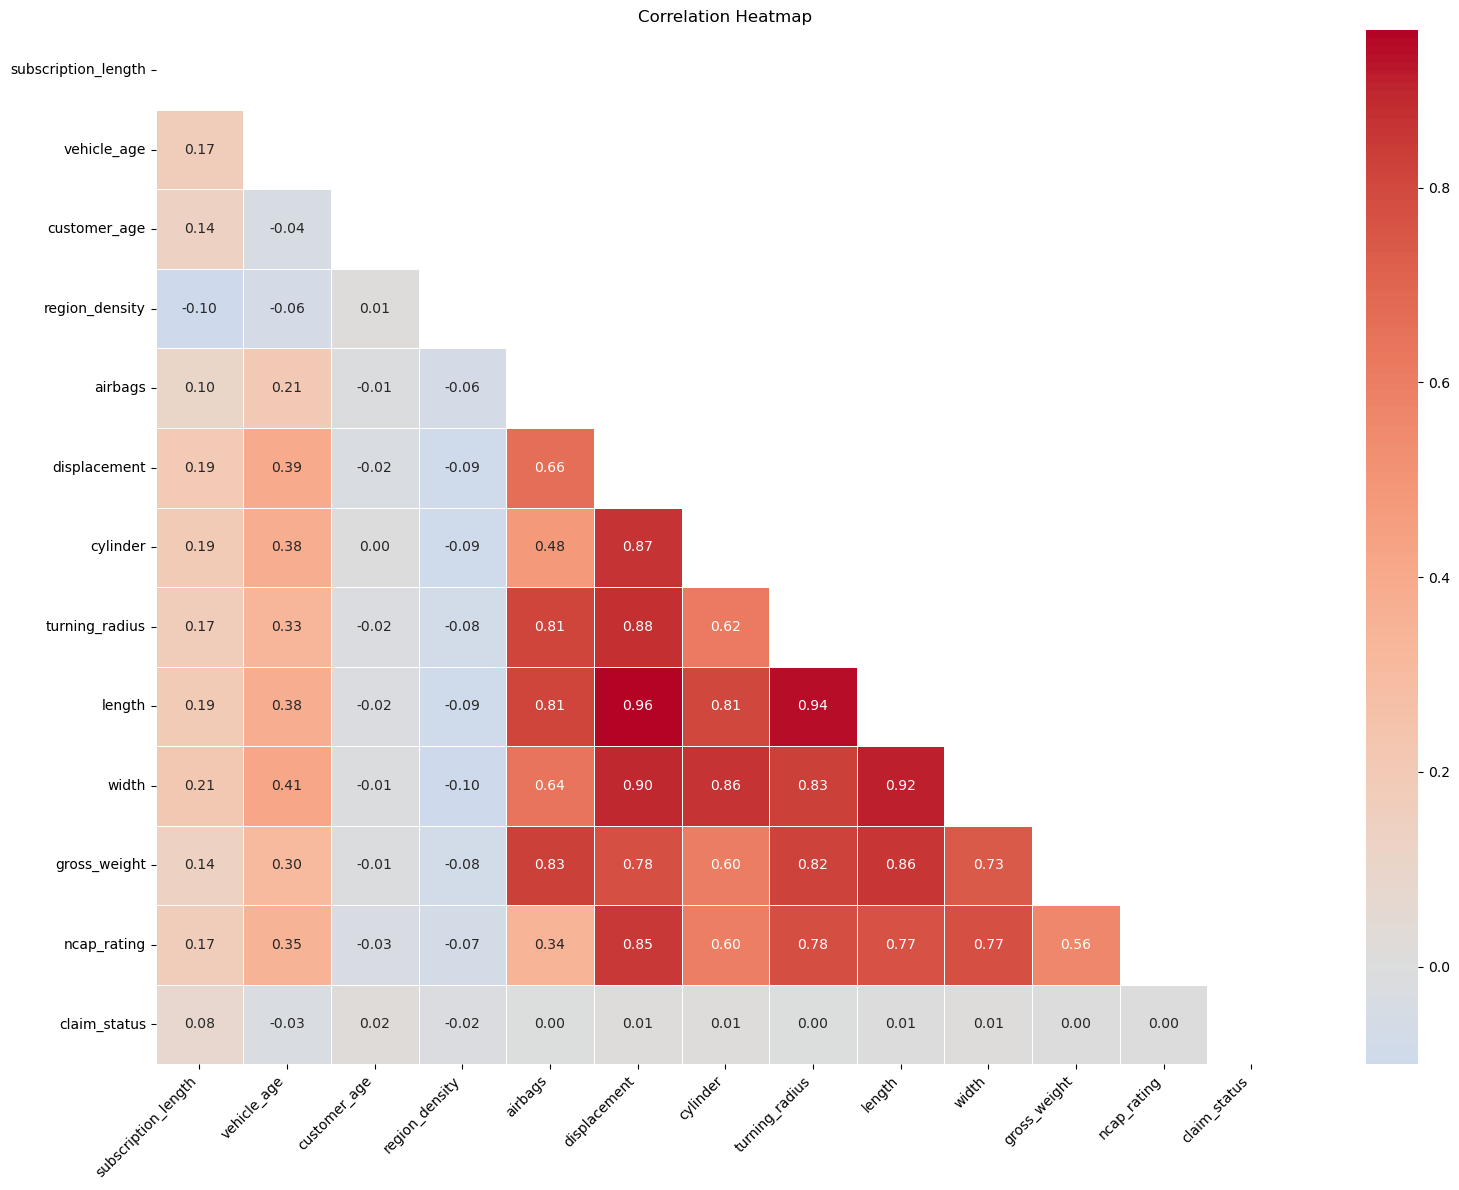

In [32]:
#Correlation analysis
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()

#Created a mask for upper triangle
mask=np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr,mask=mask, annot=True, cmap="coolwarm",center=0,linewidths=0.5, fmt=".2f" )
plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
# Sort the correlations with PerformanceRating in descending order
correlation_performance = corr['claim_status'].abs().sort_values(ascending=False)
correlation_performance

claim_status           1.000000
subscription_length    0.078738
vehicle_age            0.028172
customer_age           0.022234
region_density         0.017808
cylinder               0.013434
width                  0.009947
displacement           0.007678
length                 0.006495
gross_weight           0.003894
ncap_rating            0.003800
airbags                0.002789
turning_radius         0.002724
Name: claim_status, dtype: float64

### Correlation Analysis Insights

The correlation heatmap shows strong relationships among vehicle-related features such as length, width, turning radius, displacement, and cylinder count. This indicates multicollinearity, as these variables capture similar aspects of vehicle size and engine capacity.

The target variable (claim_status) shows weak linear correlation with all features, suggesting that claim prediction depends on complex, non-linear interactions rather than simple linear relationships.

This supports the use of advanced machine learning models such as Random Forest and Gradient Boosting, which can capture non-linear patterns effectively.

Additionally, safety-related features (e.g., airbags) show moderate correlation with engine-related variables, indicating that higher-end vehicles tend to include more safety features.

In [39]:
#Exclude the target from outlier analysis
num_cols = df.drop(columns=["claim_status"]).select_dtypes(include=["int64", "float64"]).columns
#Outlier Detection using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return lower_bound, upper_bound, len(outliers)

#Applied detection
outlier_summary = []

for col in num_cols:
    lower, upper, count = detect_outliers_iqr(df, col)
    outlier_summary.append([col, lower, upper, count])

outlier_df = pd.DataFrame(outlier_summary, columns=["Column", "Lower Bound", "Upper Bound", "Outlier Count"])
outlier_df

,Column,Lower Bound,Upper Bound,Outlier Count
0,subscription_length,-10.35,22.85,0
1,vehicle_age,-2.30,4.90,269
2,customer_age,24.00,64.00,282
3,region_density,-25224.50,58339.50,3647
4,airbags,-4.00,12.00,0
5,displacement,-249.50,2538.50,0
6,cylinder,1.50,5.50,0
7,turning_radius,4.00,5.60,0
8,length,2620.00,4820.00,0
9,width,1155.00,2115.00,0


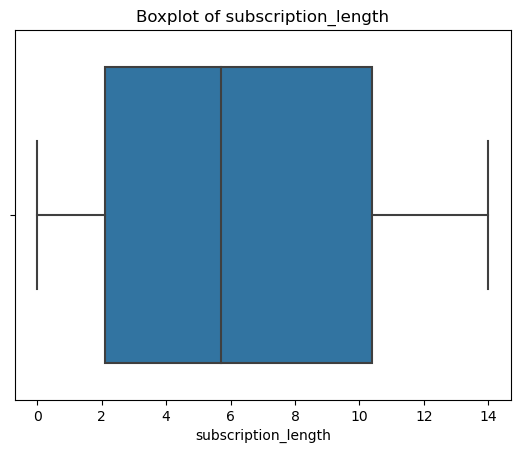

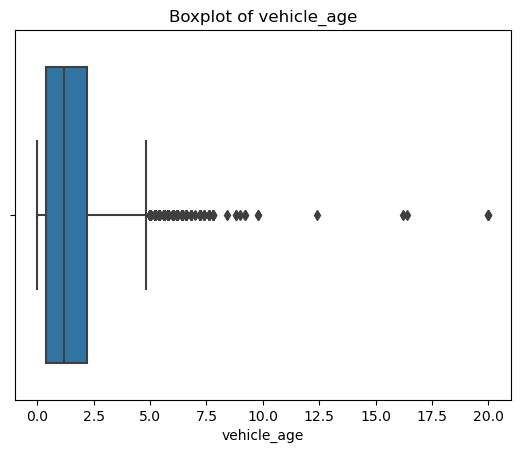

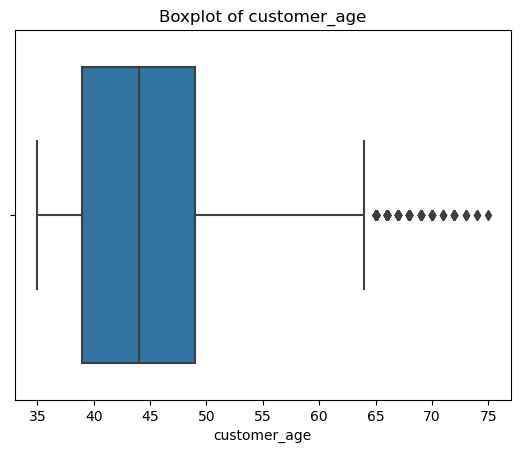

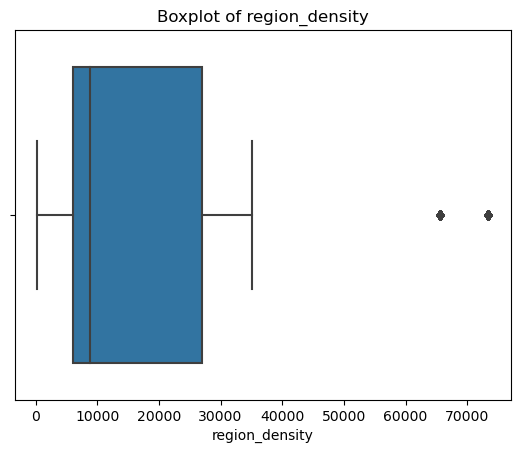

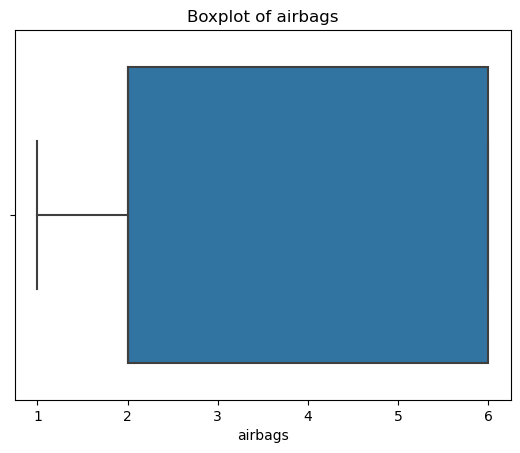

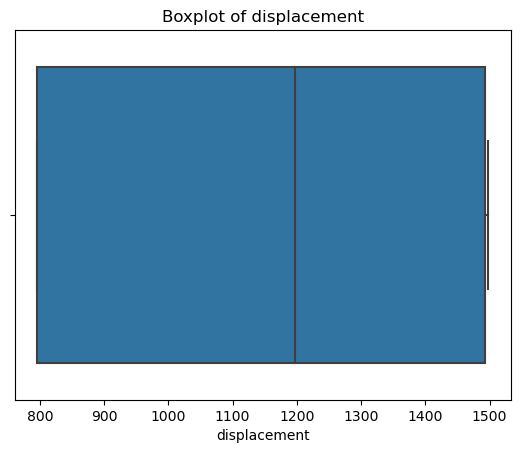

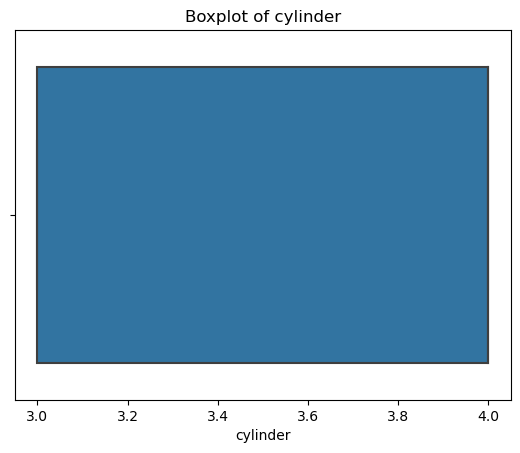

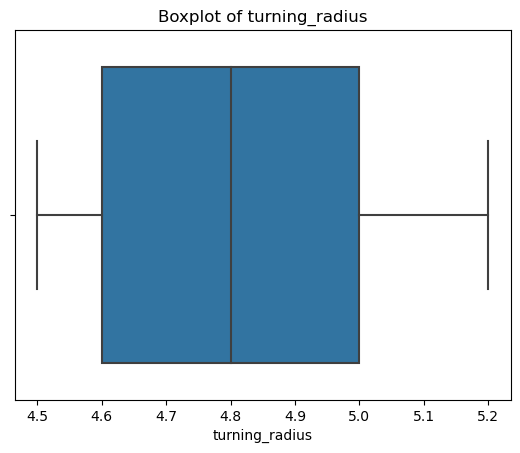

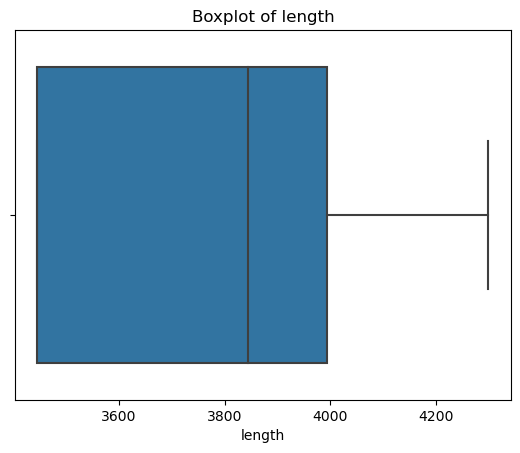

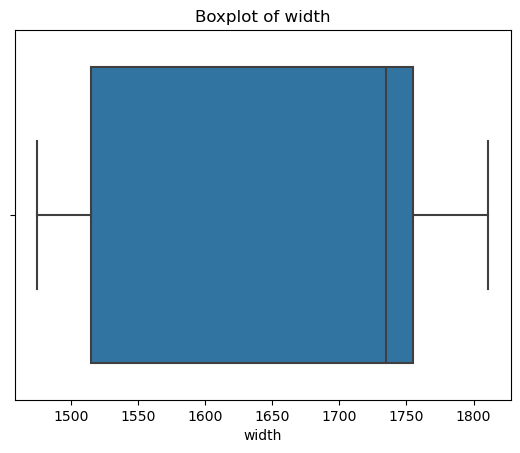

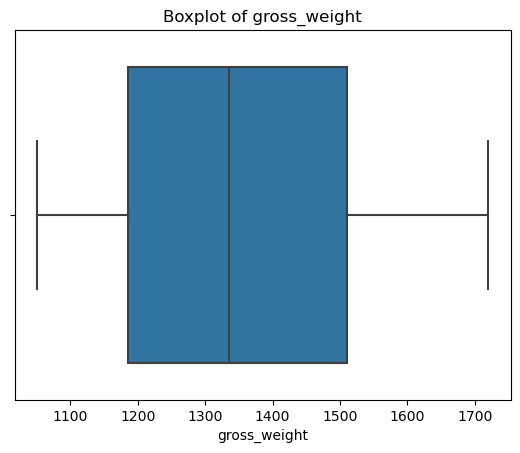

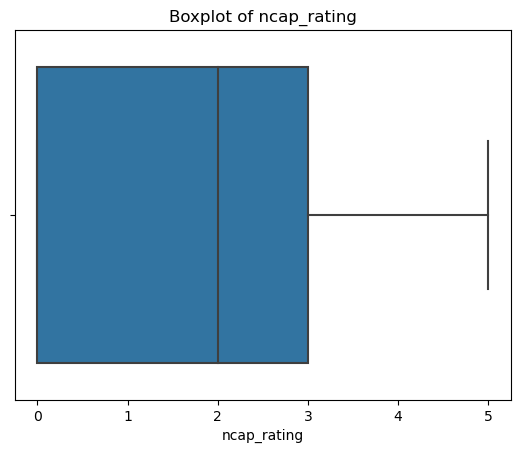

In [40]:
#Visualized outliers using boxplot
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [41]:
#Outlier handling

df_out = df.copy()

def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data[column] = np.clip(data[column], lower_bound, upper_bound)
    
    return data

# Apply capping
for col in num_cols:
    df_out = cap_outliers(df_out, col)

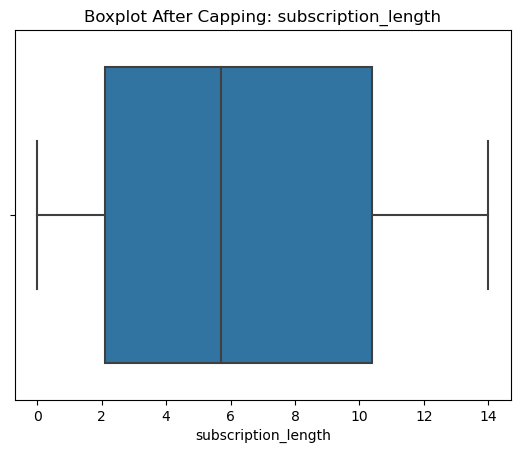

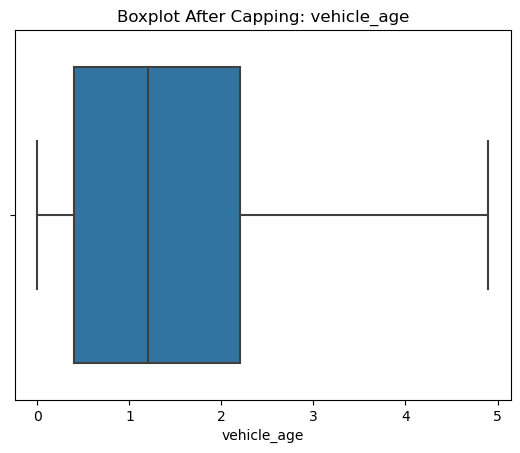

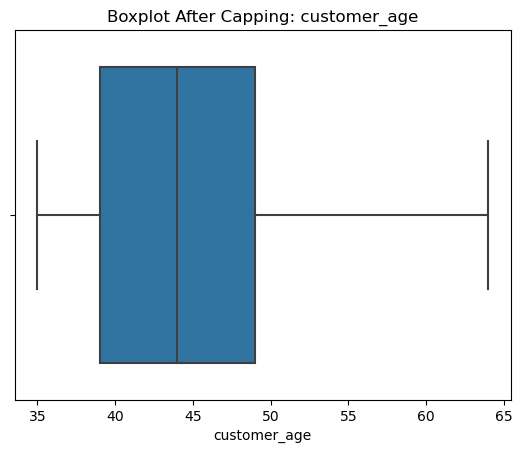

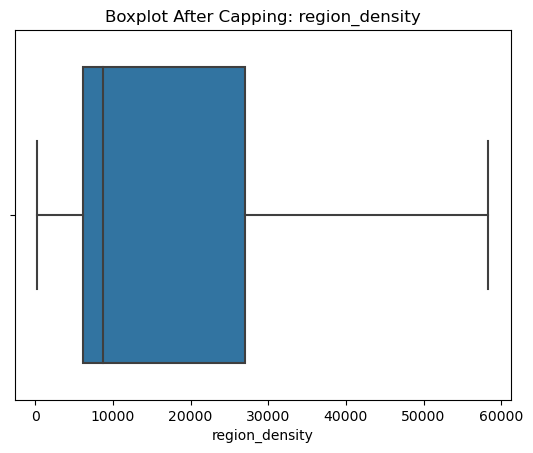

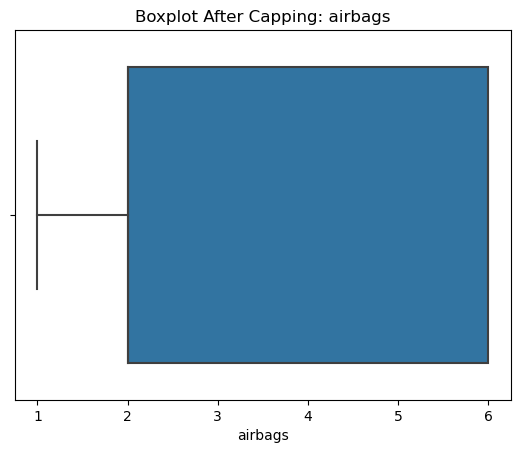

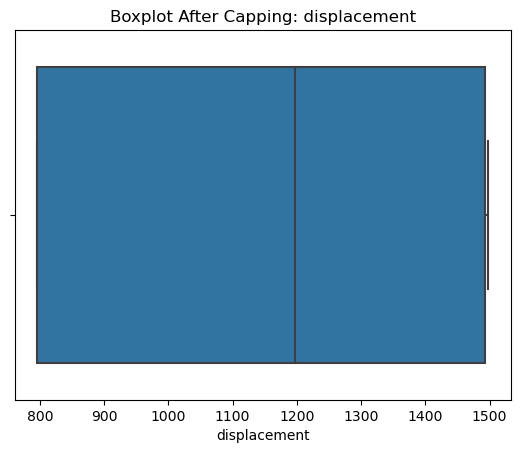

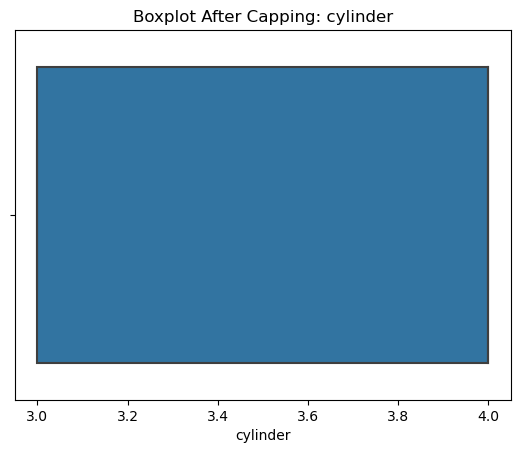

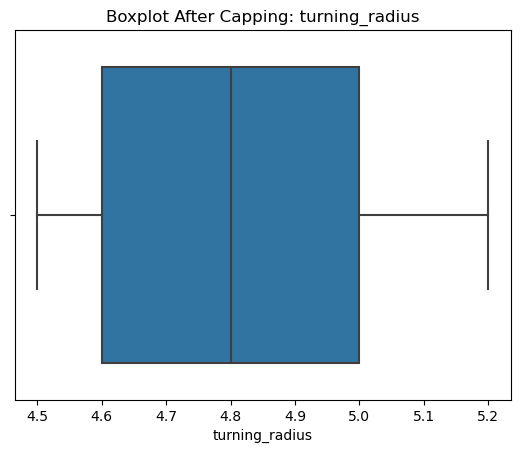

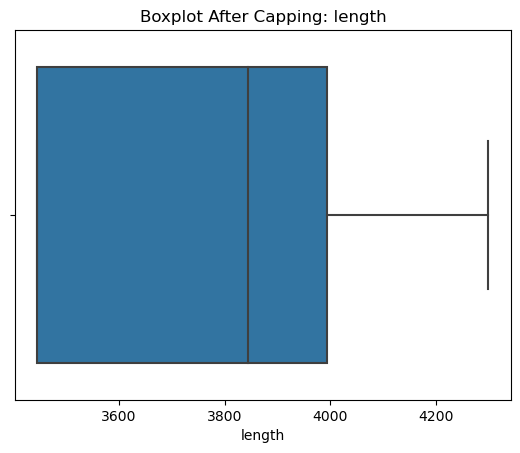

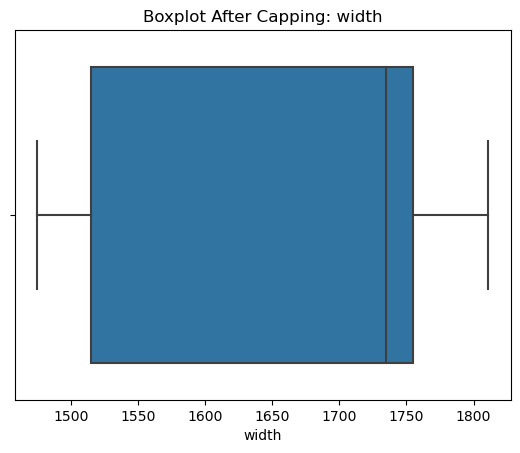

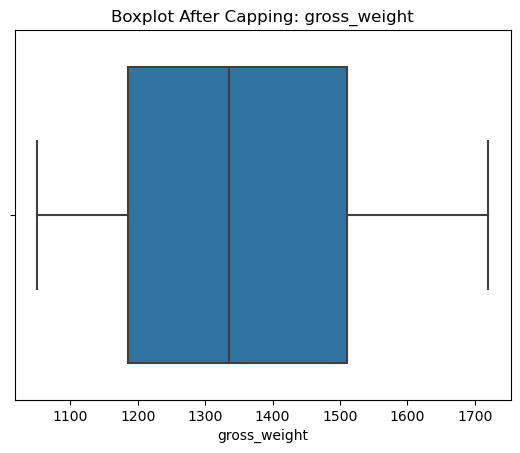

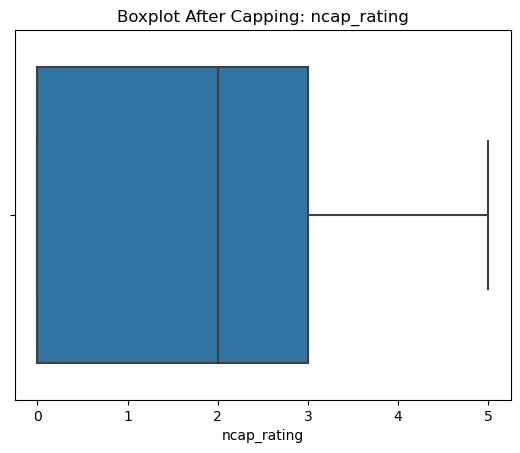

In [42]:
#Verified after capping

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df_out[col])
    plt.title(f"Boxplot After Capping: {col}")
    plt.show()

### Outlier Analysis Insights

Outliers were identified primarily in region_density, customer_age, and vehicle_age. 

The region_density variable exhibited significant right skew, representing highly urbanized areas with increased traffic exposure. These values were retained but capped to preserve their impact on insurance risk.

Customer_age and vehicle_age outliers were also capped rather than removed, as they represent valid high-risk groups in insurance modelling.

The target variable (claim_status) was excluded from outlier treatment since it is binary.

In [43]:
Q1 = df_out["vehicle_age"].quantile(0.25)
Q3 = df_out["vehicle_age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Check for remaining outliers
df_out[(df_out["vehicle_age"] < lower) | (df_out["vehicle_age"] > upper)]

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status


In [44]:
Q1 = df_out["region_density"].quantile(0.25)
Q3 = df_out["region_density"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Check for remaining outliers
df_out[(df_out["region_density"] < lower) | (df_out["region_density"] > upper)]

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status


In [45]:
Q1 = df_out["customer_age"].quantile(0.25)
Q3 = df_out["customer_age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Check for remaining outliers
df_out[(df_out["customer_age"] < lower) | (df_out["customer_age"] > upper)]

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status


### Outlier Treatment Verification

Post-treatment validation confirmed that no observations fall outside the IQR bounds, indicating that outliers were successfully handled using capping. This ensures that extreme values do not distort model performance while preserving important risk-related information.

In [46]:
#Saved the cleaned data
df_out.to_csv("../data/cleaned_insurance_data.csv", index=False)
print("✅ File saved successfully")

✅ File saved successfully
